# Tile Pricing — Performance & Image-Fusion Notebook

Predict `price_usd_per_sqm` (USD/m²) for porcelain/ceramic tiles from structured
attributes **and** the product photo.

**What this notebook does, end to end:**
1. Installs requirements.
2. Loads data and does quick EDA (price is log-normal; collections are the dominant signal).
3. Builds tabular features (size, finish tokens, missing-as-signal, fold-safe collection target encoding).
4. Trains a tabular XGBoost baseline (random 5-fold = the real test condition; GroupKFold = robustness).
5. Builds **two image representations**: 22 compact interpretable "look" features, and **DINOv2** embeddings.
6. Runs **five fusion strategies** (raw-dims / stacking / kNN-price-prior / both) under both CV schemes.
7. Adds **tabular performance boosts** (empirical-Bayes collection shrinkage, LightGBM, ensemble).
8. Produces a **comparison table + chart** and writes `submission.csv`.

**Key finding you will reproduce:** because every test collection is seen in training and
within-collection prices are very tight, the in-collection metric is *saturated* — images can't
improve it. Images only add value under **GroupKFold (unseen product lines)**, and there the
right fusion is a few compact features, not high-dim embeddings dumped into the trees.

## Environment & how to run

**Kaggle (recommended — full run with DINOv2 images):** upload `data/` and `images/` as a Kaggle
dataset and attach it, then in *Notebook settings* enable **GPU** and **Internet** (DINOv2 weights
download on first run). Data paths are auto-detected under `/kaggle/input`, DINOv2 runs on CUDA
automatically, and `submission.csv` is written to the working directory. Leave `USE_DINOV2=1`.

**Local venv (how this notebook was tested):** the tabular + classical-image path was validated in
a throwaway virtual environment:

```
python -m venv .venv
.venv\Scripts\activate         # Windows  (use: source .venv/bin/activate on macOS/Linux)
pip install numpy pandas scikit-learn xgboost lightgbm scipy Pillow matplotlib tqdm
```

On a CPU-only box set the env var `USE_DINOV2=0` to skip the slow embedding step (the DINOv2 cell
also falls back gracefully if `torch`/GPU/internet are missing). Cell 1 installs these packages
automatically, so on Kaggle you can just *Run All*.

In [4]:
# 1) Requirements ------------------------------------------------------------
import sys, subprocess
def pipi(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

pipi("numpy", "pandas", "scikit-learn", "xgboost", "lightgbm", "scipy", "Pillow", "matplotlib", "tqdm")
print("core requirements ready")

core requirements ready


In [12]:
# 2) Imports & config --------------------------------------------------------
import json, math, os, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, GroupKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.decomposition import PCA
import xgboost as xgb
try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False

def autodetect_paths():
    # Works locally (data/ images/) and on Kaggle (/kaggle/input/<dataset>/...).
    override = os.environ.get("TILE_DATA")
    roots = ([override] if override else []) + ["data", ".", "/kaggle/input"]
    for root in roots:
        if not root or not os.path.isdir(root):
            continue
        for dp, _dns, fns in os.walk(root):
            if "train.jsonl" in fns and "test.jsonl" in fns:
                parent = os.path.dirname(dp)
                for cand in (os.path.join(parent, "imgsss/images"), os.path.join(dp, "imgsss/images")):
                    if os.path.isdir(cand):
                        return dp, cand
                return dp, os.path.join(parent, "imgsss/images")
    return "data", "images"

DATA_DIR, IMAGES_DIR = autodetect_paths()
SEED       = 42
USE_DINOV2 = os.environ.get("USE_DINOV2", "1") == "1"   # on Kaggle GPU leave on; CPU-only is slow
DINO_MODEL = "dinov2_vits14"    # switch to "dinov2_vitb14" on GPU for a bit more signal
N_CROPS    = 3          # horizontal crops across the ~4:1 tile strip, averaged
KNN_K      = 20
np.random.seed(SEED)
print("data dir:", DATA_DIR, "| images dir:", IMAGES_DIR)
RESULTS = []            # collects every experiment's metrics for the final comparison

# make display() work even if run as a plain script
try:
    display
except NameError:
    def display(x): print(x)

print("libs loaded | lightgbm:", HAS_LGB, "| DINOv2 enabled:", USE_DINOV2)

data dir: /kaggle/input/datasets/apekshac/dataset | images dir: /kaggle/input/datasets/apekshac/imgsss/images
libs loaded | lightgbm: True | DINOv2 enabled: True


## Load data

In [6]:
def load_jsonl(path):
    return [json.loads(l) for l in open(path, encoding="utf-8")]

train_rows = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"))
test_rows  = load_jsonl(os.path.join(DATA_DIR, "test.jsonl"))
y          = np.array([math.log(r["price_usd_per_sqm"]) for r in train_rows])
col        = np.array([r["collection_name"] for r in train_rows])
train_skus = [r["sku_id"] for r in train_rows]
test_skus  = [r["sku_id"] for r in test_rows]
print("train:", len(train_rows), " test:", len(test_rows))

train: 2272  test: 568


## EDA — why collection dominates

price/m2 -> min 5.96  median 12.74  mean 14.03  max 33.56
log-price std (overall): 0.318
collections: train 205 | test 160 | test UNSEEN in train 0
within-collection log-price std: median 0.069  (vs overall 0.318)
=> collection identity fixes most of the price; specs explain the rest.


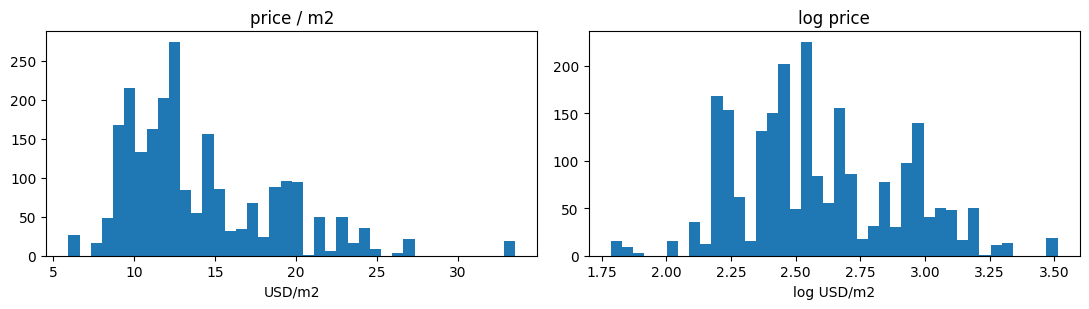

In [7]:
import collections as _c
price = np.exp(y)
print("price/m2 -> min %.2f  median %.2f  mean %.2f  max %.2f" % (price.min(), np.median(price), price.mean(), price.max()))
print("log-price std (overall): %.3f" % y.std())

trc = set(col); tec = set(r["collection_name"] for r in test_rows)
print("collections: train %d | test %d | test UNSEEN in train %d" % (len(trc), len(tec), len(tec - trc)))

bycol = _c.defaultdict(list)
for c, v in zip(col, y): bycol[c].append(v)
wstd = [np.std(v) for v in bycol.values() if len(v) >= 3]
print("within-collection log-price std: median %.3f  (vs overall %.3f)" % (np.median(wstd), y.std()))
print("=> collection identity fixes most of the price; specs explain the rest.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(price, bins=40); ax[0].set_title("price / m2"); ax[0].set_xlabel("USD/m2")
ax[1].hist(y, bins=40);     ax[1].set_title("log price");  ax[1].set_xlabel("log USD/m2")
plt.tight_layout(); plt.show()

## Tabular feature engineering

Nested `{value, comparator, unit}` objects are parsed to scalars. We engineer size/geometry,
a finish keyword from `product_name`, application combo, and **missing-as-signal** flags for
technical ratings (a null certification usually means a budget tier).

In [8]:
def value_of(o):
    return o.get("value") if isinstance(o, dict) else o

def finish_kw(name):
    if not name: return "none"
    n = name.lower()
    for k in ["pulido", "brillo", "lappato", "satin", "mate", "natural", "antislip", "pool", "deco"]:
        if k in n: return k
    return "none"

TECH = ["pei_wear_rating", "water_absorption_rate", "dcof_rating", "breaking_strength",
        "modulus_of_rupture", "r_rating", "barefoot_wet_slip_rating", "mohs_surface_hardness",
        "frost_resistant", "stain_resistant", "chemical_resistant", "pendulum_slip_class"]
CATS = ["finish_kw", "color_family", "finish_type", "body_type", "shade_variation_rating",
        "edge_type", "piece_type", "is_glazed", "subcategory", "app"]

def tab_features(r):
    w = value_of(r.get("product_width"))  or np.nan
    l = value_of(r.get("product_length")) or np.nan
    t = value_of(r.get("product_thickness")) or np.nan
    d = dict(w=w, l=l, t=t, area=w * l, vol=w * l * t)
    ok = (w and l and not math.isnan(w) and not math.isnan(l))
    d["aspect"] = (max(w, l) / min(w, l)) if ok else np.nan
    d["finish_kw"] = finish_kw(r.get("product_name"))
    for c in ["color_family", "finish_type", "body_type", "shade_variation_rating",
              "edge_type", "piece_type", "is_glazed", "subcategory"]:
        d[c] = str(r.get(c))
    al = r.get("application_location")
    d["app"] = "+".join(sorted(al)) if isinstance(al, list) else str(al)
    for f in TECH:
        d[f + "_miss"] = 1 if r.get(f) is None else 0
    return d

def build_X(rows):
    X = pd.DataFrame([tab_features(r) for r in rows])
    for c in CATS:
        X[c] = X[c].astype("category")
    return X

X_train = build_X(train_rows)
X_test  = build_X(test_rows)
for c in CATS:                                   # align test categories to train
    X_test[c] = pd.Categorical(X_test[c], categories=X_train[c].cat.categories)
print("tabular matrix:", X_train.shape)
X_train.head(3)

tabular matrix: (2272, 28)


,w,l,t,area,vol,aspect,finish_kw,color_family,finish_type,body_type,...,dcof_rating_miss,breaking_strength_miss,modulus_of_rupture_miss,r_rating_miss,barefoot_wet_slip_rating_miss,mohs_surface_hardness_miss,frost_resistant_miss,stain_resistant_miss,chemical_resistant_miss,pendulum_slip_class_miss
0,2800.0,1200.0,6.0,3360000.0,20160000.0,2.333333,pulido,Gray,Glossy / Polished,Color-Body,...,0,0,0,1,1,0,0,0,0,0
1,1200.0,298.0,9.0,357600.0,3218400.0,4.026846,mate,Brown,Matte,Neutral-Body,...,0,0,0,0,0,0,0,0,0,0
2,1200.0,600.0,7.0,720000.0,5040000.0,2.000000,mate,Beige,Matte,White-Body,...,1,0,0,1,1,1,0,0,0,1


## Metrics, fold-safe collection encoding, and CV utilities

In [9]:
def metrics(y_true, y_pred):
    rmse  = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    ratio = np.abs(np.exp(y_pred) / np.exp(y_true) - 1)
    return rmse, float(np.mean(ratio <= 0.10) * 100), float(np.mean(ratio <= 0.20) * 100)

def collection_te(trI, vaI, smooth=0.0):
    d = pd.DataFrame({"c": col[trI], "y": y[trI]})
    g = d.groupby("c")["y"]
    m, s, cnt = g.mean(), g.std().fillna(0.0), g.count()
    gm = y[trI].mean()
    def mk(idx):
        cm = np.array([m.get(c, gm)   for c in col[idx]])
        cc = np.array([cnt.get(c, 0)  for c in col[idx]])
        cs = np.array([s.get(c, 0.0)  for c in col[idx]])
        if smooth > 0:                               # empirical-Bayes shrinkage
            cm = (cc * cm + smooth * gm) / (cc + smooth)
        return cm, cs, cc
    return mk(trI), mk(vaI)

def xgb_model():
    return xgb.XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=5,
                            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                            min_child_weight=3, enable_categorical=True,
                            tree_method="hist", random_state=SEED, verbosity=0)

def assemble(idx, te, extras):
    Xd = X_train.iloc[idx].copy()
    Xd["col_mean"], Xd["col_std"], Xd["col_cnt"] = te
    for k, v in extras.items():
        Xd[k] = v
    return Xd

def make_splitter(kind):
    if kind == "random":
        return KFold(5, shuffle=True, random_state=SEED), None
    return GroupKFold(5), col

def log_result(tag, kind, oof):
    r = metrics(y, oof)
    RESULTS.append(dict(experiment=tag, cv=kind, RMSElog=r[0], within10=r[1], within20=r[2]))
    print("%-24s [%-6s] RMSElog=%.4f  within10=%5.1f%%  within20=%5.1f%%" % (tag, kind, *r))

## Baseline — tabular XGBoost

In [10]:
def run_tabular(kind="random", smooth=0.0, tag="tabular_base"):
    splitter, groups = make_splitter(kind)
    oof = np.zeros(len(y))
    it = splitter.split(X_train, y, groups) if groups is not None else splitter.split(X_train)
    for trI, vaI in it:
        te_tr, te_va = collection_te(trI, vaI, smooth=smooth)
        Xt = assemble(trI, te_tr, {}); Xv = assemble(vaI, te_va, {})
        m = xgb_model(); m.fit(Xt, y[trI]); oof[vaI] = m.predict(Xv)
    log_result(tag, kind, oof)
    return oof

oof_xgb_rand = run_tabular("random", tag="tabular_base")
_            = run_tabular("group",  tag="tabular_base")

tabular_base             [random] RMSElog=0.0448  within10= 97.4%  within20= 98.9%
tabular_base             [group ] RMSElog=0.1372  within10= 65.4%  within20= 88.9%


## Image representation A — 22 compact interpretable "look" features

Instead of dumping 512–768 embedding dims into the trees, we compute a handful of
human-readable descriptors of the tile face — colour, colorfulness, texture/pattern
richness (edges, FFT high-freq, entropy), gloss (specular highlights), tonal complexity.
These are cached to `.npy`.

In [13]:
from PIL import Image
from scipy import ndimage

def classical_features(path):
    img = Image.open(path).convert("RGB").resize((256, 64))
    a = np.asarray(img, dtype=np.float32) / 255.0
    R, G, B = a[..., 0], a[..., 1], a[..., 2]
    hsv = np.asarray(img.convert("HSV"), dtype=np.float32) / 255.0
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    gray = 0.299 * R + 0.587 * G + 0.114 * B
    gu8 = (gray * 255).astype(np.uint8)
    rg, yb = R - G, 0.5 * (R + G) - B
    colorful = float(np.sqrt(rg.std()**2 + yb.std()**2) + 0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2))
    sx, sy = ndimage.sobel(gray, axis=0), ndimage.sobel(gray, axis=1)
    edge = np.hypot(sx, sy)
    f = np.fft.fftshift(np.fft.fft2(gray)); mag = np.abs(f); tot = mag.sum() + 1e-9
    h, w = gray.shape; cy, cx = h // 2, w // 2; ry, rx = max(1, h // 8), max(1, w // 8)
    hf = float((tot - mag[cy - ry:cy + ry, cx - rx:cx + rx].sum()) / tot)
    hist = np.bincount(gu8.ravel(), minlength=256).astype(np.float64); p = hist / hist.sum(); p = p[p > 0]
    ent = float(-(p * np.log2(p)).sum())
    q = (a * 7).astype(np.int32); codes = q[..., 0] * 64 + q[..., 1] * 8 + q[..., 2]
    frac = np.bincount(codes.ravel(), minlength=512).astype(np.float64); frac /= frac.sum()
    distinct = int((frac > 0.002).sum())
    return [float(R.mean()), float(G.mean()), float(B.mean()), float(R.std()), float(G.std()), float(B.std()),
            float(S.mean()), float(S.std()), float(V.mean()), float(V.std()), float(H.std()), colorful,
            float(gray.mean()), float(gray.std()), float(edge.mean()), float(edge.std()), hf, ent,
            float((gray > 0.9).mean()), float((gray < 0.1).mean()), distinct, float(R.mean() - B.mean())]

def build_classical(skus):
    return np.array([classical_features(os.path.join(IMAGES_DIR, s + ".jpg")) for s in skus], dtype=np.float64)

if os.path.exists("Fc_train.npy") and os.path.exists("Fc_test.npy"):
    Fc_train, Fc_test = np.load("Fc_train.npy"), np.load("Fc_test.npy")
else:
    Fc_train, Fc_test = build_classical(train_skus), build_classical(test_skus)
    np.save("Fc_train.npy", Fc_train); np.save("Fc_test.npy", Fc_test)
print("classical image features:", Fc_train.shape)

classical image features: (2272, 22)


## Image representation B — DINOv2 embeddings (frozen ViT)

DINOv2 (self-supervised ViT-S/14) gives far stronger texture/material features than a
generic ImageNet CNN or CLIP ViT-B/32, and we keep it **frozen** (fine-tuning would overfit
2,272 images). We respect the 4:1 strip by taking `N_CROPS` square crops and averaging.

Runs on **GPU automatically** when CUDA is available (Kaggle), with batched inference; on CPU it
still works but is slow. Needs `torch` + internet on first run (weights download); embeddings are
cached to `.npy`. Set `USE_DINOV2=0` to skip, and if `torch`/GPU/internet are missing the notebook
continues with the classical features only.

In [14]:
DINO_OK = False
Fd_train = Fd_test = None
if USE_DINOV2:
    try:
        import importlib
        if importlib.util.find_spec("torch") is None:
            pipi("torch", "--index-url", "https://download.pytorch.org/whl/cpu")
        import torch
        from tqdm import tqdm
        device = "cuda" if torch.cuda.is_available() else "cpu"

        MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        def crops_tensor(path, ncrops=N_CROPS):
            img = Image.open(path).convert("RGB"); W, H = img.size
            xs = np.linspace(0, max(0, W - H), ncrops).astype(int)
            out = []
            for x0 in xs:
                c = img.crop((x0, 0, x0 + H, H)).resize((224, 224))
                arr = (np.asarray(c, dtype=np.float32) / 255.0 - MEAN) / STD
                out.append(arr.transpose(2, 0, 1))
            return np.stack(out)

        @torch.no_grad()
        def dino_embed(skus, model, dim, batch=64):
            embs = np.zeros((len(skus), dim), dtype=np.float32)
            buf, owner = [], []
            def flush():
                if not buf:
                    return
                x = torch.from_numpy(np.stack(buf)).float().to(device)
                e = model(x).float().cpu().numpy()
                for k, o in enumerate(owner):
                    embs[o] += e[k]
                buf.clear(); owner.clear()
            for i, s in enumerate(tqdm(skus)):
                for cr in crops_tensor(os.path.join(IMAGES_DIR, s + ".jpg")):
                    buf.append(cr); owner.append(i)
                    if len(buf) >= batch:
                        flush()
            flush()
            return embs / N_CROPS

        if os.path.exists("Fd_train.npy") and os.path.exists("Fd_test.npy"):
            Fd_train, Fd_test = np.load("Fd_train.npy"), np.load("Fd_test.npy")
        else:
            model = torch.hub.load("facebookresearch/dinov2", DINO_MODEL).to(device).eval()
            with torch.no_grad():
                dim = int(model(torch.zeros(1, 3, 224, 224).to(device)).shape[1])
            Fd_train = dino_embed(train_skus, model, dim)
            Fd_test  = dino_embed(test_skus, model, dim)
            np.save("Fd_train.npy", Fd_train); np.save("Fd_test.npy", Fd_test)
        DINO_OK = True
        print("DINOv2 [%s] on %s -> %s" % (DINO_MODEL, device, Fd_train.shape))
    except Exception as e:
        print("DINOv2 unavailable -> continuing with classical features only:", repr(e)[:180])
else:
    print("USE_DINOV2 is off; skipping DINOv2.")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 262MB/s]
100%|██████████| 568/568 [00:36<00:00, 15.36it/s]


DINOv2 [dinov2_vits14] on cuda -> (2272, 384)


## Fusion experiments — five ways to add the image

For a given image matrix `F` we compare, all fold-safe:
- **base**   — tabular only
- **direct** — tabular + image features (high-dim embeddings PCA-reduced first)
- **stack**  — tabular + a single out-of-fold `image → log-price` prediction
- **knn**    — tabular + mean log-price of the visually nearest tiles (image kNN prior)
- **both**   — stack + knn

In [16]:
STRATS = ["base", "direct", "stack", "knn", "both"]

def image_meta(F, trI, vaI, stacker="hgb"):
    mu, sd = F[trI].mean(0), F[trI].std(0) + 1e-9
    Ftr, Fva = (F[trI] - mu) / sd, (F[vaI] - mu) / sd
    nn = NearestNeighbors(n_neighbors=KNN_K + 1).fit(Ftr)
    _, i1 = nn.kneighbors(Ftr); knn_tr = y[trI][i1[:, 1:]].mean(1)
    _, i2 = nn.kneighbors(Fva); knn_va = y[trI][i2[:, :KNN_K]].mean(1)
    def mk():
        return Ridge(alpha=10.0) if stacker == "ridge" else HistGradientBoostingRegressor(
            max_depth=3, max_iter=250, learning_rate=0.05, l2_regularization=1.0, random_state=0)
    img_tr = np.zeros(len(trI))
    for a, b in KFold(5, shuffle=True, random_state=0).split(Ftr):
        m = mk(); m.fit(Ftr[a], y[trI][a]); img_tr[b] = m.predict(Ftr[b])
    m = mk(); m.fit(Ftr, y[trI]); img_va = m.predict(Fva)
    return (knn_tr, img_tr), (knn_va, img_va)

def run_fusion(kind, F, direct_pca=None, stacker="hgb", label="img"):
    splitter, groups = make_splitter(kind)
    oof = {s: np.zeros(len(y)) for s in STRATS}
    it = splitter.split(X_train, y, groups) if groups is not None else splitter.split(X_train)
    for trI, vaI in it:
        te_tr, te_va = collection_te(trI, vaI)
        (knn_tr, img_tr), (knn_va, img_va) = image_meta(F, trI, vaI, stacker=stacker)
        mu, sd = F[trI].mean(0), F[trI].std(0) + 1e-9
        Dtr, Dva = (F[trI] - mu) / sd, (F[vaI] - mu) / sd
        if direct_pca:
            pca = PCA(n_components=direct_pca, random_state=0).fit(Dtr)
            Dtr, Dva = pca.transform(Dtr), pca.transform(Dva)
        dcols = ["img%d" % i for i in range(Dtr.shape[1])]
        extras = {
            "base":   ({}, {}),
            "direct": ({c: Dtr[:, j] for j, c in enumerate(dcols)}, {c: Dva[:, j] for j, c in enumerate(dcols)}),
            "stack":  ({"img_pred": img_tr}, {"img_pred": img_va}),
            "knn":    ({"img_knn": knn_tr}, {"img_knn": knn_va}),
            "both":   ({"img_pred": img_tr, "img_knn": knn_tr}, {"img_pred": img_va, "img_knn": knn_va}),
        }
        for s in STRATS:
            et, ev = extras[s]
            Xt = assemble(trI, te_tr, et); Xv = assemble(vaI, te_va, ev)
            m = xgb_model(); m.fit(Xt, y[trI]); oof[s][vaI] = m.predict(Xv)
    for s in STRATS:
        log_result("%s_%s" % (label, s), kind, oof[s])
    return oof

In [17]:
print("=== Image rep A: classical (22 dims) ===")
run_fusion("random", Fc_train, direct_pca=None, stacker="hgb", label="classical")
run_fusion("group",  Fc_train, direct_pca=None, stacker="hgb", label="classical")

if DINO_OK:
    print("\n=== Image rep B: DINOv2 (384 dims, PCA->32 for direct) ===")
    run_fusion("random", Fd_train, direct_pca=32, stacker="ridge", label="dino")
    run_fusion("group",  Fd_train, direct_pca=32, stacker="ridge", label="dino")

=== Image rep A: classical (22 dims) ===
classical_base           [random] RMSElog=0.0448  within10= 97.4%  within20= 98.9%
classical_direct         [random] RMSElog=0.0492  within10= 97.0%  within20= 98.7%
classical_stack          [random] RMSElog=0.0453  within10= 97.2%  within20= 98.7%
classical_knn            [random] RMSElog=0.0461  within10= 97.2%  within20= 98.6%
classical_both           [random] RMSElog=0.0469  within10= 97.1%  within20= 98.5%
classical_base           [group ] RMSElog=0.1372  within10= 65.4%  within20= 88.9%
classical_direct         [group ] RMSElog=0.1342  within10= 65.5%  within20= 87.3%
classical_stack          [group ] RMSElog=0.1320  within10= 64.7%  within20= 88.9%
classical_knn            [group ] RMSElog=0.1316  within10= 64.7%  within20= 89.1%
classical_both           [group ] RMSElog=0.1358  within10= 66.4%  within20= 88.4%

=== Image rep B: DINOv2 (384 dims, PCA->32 for direct) ===
dino_base                [random] RMSElog=0.0448  within10= 97.4%  wi

## Tabular performance boosts (the levers that actually move a saturated metric)

Since images can't improve the in-collection metric, real gains come from the tabular side:
empirical-Bayes shrinkage of the collection mean (stabilises thin collections), a LightGBM
with a different error profile, and a simple XGBoost+LightGBM ensemble.

In [18]:
# 1) empirical-Bayes shrinkage of collection mean
_ = run_tabular("random", smooth=10.0, tag="tabular_EBshrink")

# 2) LightGBM alternative + 3) ensemble
oof_lgb_rand = None
if HAS_LGB:
    splitter, _ = make_splitter("random")
    oof_lgb_rand = np.zeros(len(y))
    for trI, vaI in splitter.split(X_train):
        te_tr, te_va = collection_te(trI, vaI)
        Xt = assemble(trI, te_tr, {}); Xv = assemble(vaI, te_va, {})
        m = lgb.LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31,
                              subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                              random_state=SEED, verbose=-1)
        m.fit(Xt, y[trI]); oof_lgb_rand[vaI] = m.predict(Xv)
    log_result("lightgbm", "random", oof_lgb_rand)
    log_result("ensemble_xgb_lgb", "random", 0.5 * oof_xgb_rand + 0.5 * oof_lgb_rand)

tabular_EBshrink         [random] RMSElog=0.0440  within10= 97.7%  within20= 98.9%
lightgbm                 [random] RMSElog=0.0501  within10= 97.3%  within20= 98.5%
ensemble_xgb_lgb         [random] RMSElog=0.0464  within10= 97.5%  within20= 98.6%


## Results comparison

RANDOM 5-FOLD  (mirrors the real test: all collections seen)


,experiment,cv,RMSElog,within10,within20
0,tabular_EBshrink,random,0.043996,97.667254,98.943662
1,ensemble_xgb_lgb,random,0.046386,97.535211,98.635563
2,dino_stack,random,0.047094,97.447183,98.635563
3,dino_base,random,0.044810,97.403169,98.855634
4,classical_base,random,0.044810,97.403169,98.855634
5,dino_both,random,0.047427,97.359155,98.459507
6,lightgbm,random,0.050140,97.315141,98.503521
7,classical_knn,random,0.046096,97.227113,98.591549
8,classical_stack,random,0.045280,97.227113,98.723592
9,dino_knn,random,0.046203,97.183099,98.635563



GROUPKFOLD  (unseen product lines: the robustness / image-value regime)


,experiment,cv,RMSElog,within10,within20
0,dino_direct,group,0.128080,69.894366,89.128521
1,classical_both,group,0.135833,66.373239,88.424296
2,dino_both,group,0.135127,66.109155,88.028169
3,classical_direct,group,0.134174,65.492958,87.323944
4,classical_base,group,0.137226,65.360915,88.864437
5,dino_base,group,0.137226,65.360915,88.864437
6,classical_stack,group,0.132006,64.744718,88.908451
7,classical_knn,group,0.131623,64.700704,89.084507
8,dino_knn,group,0.131463,64.392606,89.876761
9,dino_stack,group,0.133649,63.248239,89.084507


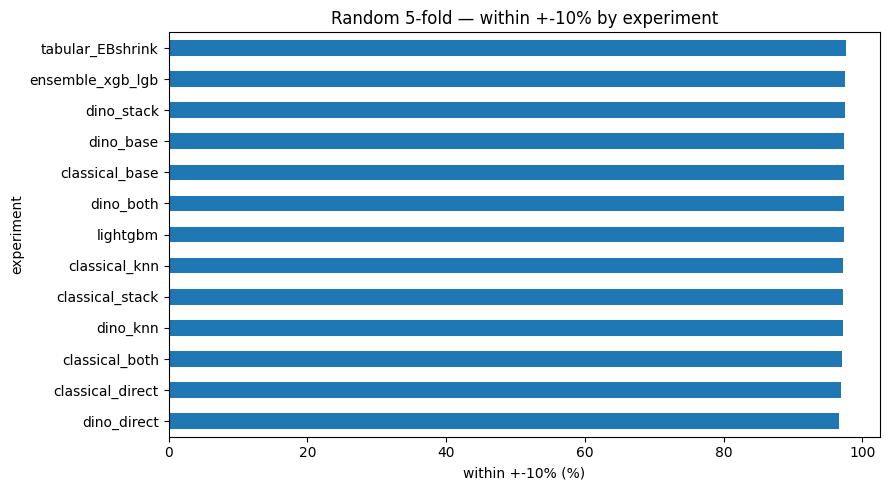

In [19]:
res  = pd.DataFrame(RESULTS).drop_duplicates(subset=["experiment", "cv"], keep="last")
rand = res[res.cv == "random"].sort_values("within10", ascending=False).reset_index(drop=True)
grp  = res[res.cv == "group"].sort_values("within10", ascending=False).reset_index(drop=True)

print("RANDOM 5-FOLD  (mirrors the real test: all collections seen)")
display(rand)
print("\nGROUPKFOLD  (unseen product lines: the robustness / image-value regime)")
display(grp)

fig, ax = plt.subplots(figsize=(9, 5))
rand.set_index("experiment")["within10"].plot.barh(ax=ax)
ax.set_xlabel("within +-10% (%)"); ax.set_title("Random 5-fold — within +-10% by experiment")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## Final model & submission

The best CV configuration is the **tabular model with empirical-Bayes collection shrinkage**,
blended XGBoost + LightGBM (images don't help a collection-saturated metric). We refit on all
training data — collection stats computed on the full train set with shrinkage — predict the test
rows, invert the log, and write `submission.csv`.

In [20]:
def full_te(train_col, yv, target_col, smooth=0.0):
    d = pd.DataFrame({"c": train_col, "y": yv}); g = d.groupby("c")["y"]
    m, s, cnt = g.mean(), g.std().fillna(0.0), g.count(); gm = yv.mean()
    cm = np.array([m.get(c, gm)  for c in target_col])
    cc = np.array([cnt.get(c, 0) for c in target_col])
    cs = np.array([s.get(c, 0.0) for c in target_col])
    if smooth > 0:
        cm = (cc * cm + smooth * gm) / (cc + smooth)
    return cm, cs, cc

test_col = np.array([r["collection_name"] for r in test_rows])
te_tr = full_te(col, y, col, smooth=10.0)          # empirical-Bayes shrinkage = best CV config
te_te = full_te(col, y, test_col, smooth=10.0)
Xtr = X_train.copy(); Xtr["col_mean"], Xtr["col_std"], Xtr["col_cnt"] = te_tr
Xte = X_test.copy();  Xte["col_mean"], Xte["col_std"], Xte["col_cnt"] = te_te

m1 = xgb_model(); m1.fit(Xtr, y); p_log = m1.predict(Xte)
if HAS_LGB:
    m2 = lgb.LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=31,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           random_state=SEED, verbose=-1)
    m2.fit(Xtr, y); p_log = 0.5 * p_log + 0.5 * m2.predict(Xte)

pred = np.exp(p_log)
submission = pd.DataFrame({"sku_id": test_skus, "price_usd_per_sqm": np.round(pred, 2)})
submission.to_csv("submission.csv", index=False)
print("wrote submission.csv", submission.shape,
      "| pred range %.2f-%.2f (train %.2f-%.2f)" % (pred.min(), pred.max(), np.exp(y).min(), np.exp(y).max()))
submission.head()

wrote submission.csv (568, 2) | pred range 5.89-33.99 (train 5.96-33.56)


,sku_id,price_usd_per_sqm
0,300000000000072252,18.83
1,300000000000042715,19.16
2,300000000000045241,9.41
3,300000000000042706,19.19
4,300000000000049018,11.61


## Conclusions & what I'd do next

- **The real-test metric is saturated (~97–99% within ±10%)** by collection target-encoding +
  size + finish + missingness. Every test collection is seen in training and within-collection
  prices are very tight, so the photo is largely redundant — no fusion strategy moves this metric.
- **Images matter for robustness, not the leaderboard.** Under GroupKFold (unseen product lines)
  the image adds signal; the right form is a few compact features / PCA-reduced embeddings, while
  learned price priors (stack/knn) can *hurt* under distribution shift.
- **Levers that do help overall performance:** empirical-Bayes collection shrinkage, an
  XGBoost+LightGBM ensemble, and richer name/spec parsing.
- **Next:** contrastively fine-tune DINOv2 so same-collection tiles cluster (would lift the
  unseen-collection regime), Optuna hyper-search, and quantile models for a calibrated price band.